In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import heapq
import seaborn as sns

In [2]:
from environment.environment import GridWorldMFG_MultiGroup

In [3]:
from trainer.amid_trainer import AMID_Trainer_MultiGroup
from solver.solver import PMFG_OMD_Solver_MultiGroup, solve_multigroup
from visualization.visualizationh import plot_heatmap

In [4]:
def plot_heatmap(data, title="Heatmap", xlabel="X-axis", ylabel="Y-axis"):
    plt.figure(figsize=(6, 5))
    sns.heatmap(data, annot=True, cmap="viridis", fmt=".2f")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

In [9]:
import yaml
import os
from pathlib import Path

def load_config(config_path="config.yaml"):
    """Load configuration from YAML file."""
    # Get the directory where the notebook is located
    notebook_dir = Path(os.getcwd())
    config_file = notebook_dir / config_path
    
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
    return config

def create_multigroup_from_config(config):
    """Create environment, solvers, and trainer from config."""
    device = config.get("device", "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    
    # Extract grid config
    grid_cfg = config["grid"]
    rows, cols = grid_cfg["rows"], grid_cfg["cols"]
    
    # Convert groups to correct format (convert lists to tuples for coordinates)
    groups = []
    for g in config["groups"]:
        groups.append({
            "source": tuple(g["source"]),
            "sink": tuple(g["sink"]),
            "mass": g["mass"]
        })
    
    # Create environment
    env = GridWorldMFG_MultiGroup(
        rows=rows, cols=cols,
        groups=groups,
        obstacles=grid_cfg.get("obstacles", []),
        device=device
    )
    
    # Create solvers
    solver_cfg = config["solver"]
    solvers = [
        PMFG_OMD_Solver_MultiGroup(
            env, group_idx=k,
            eta=solver_cfg["eta"],
            tau=solver_cfg["tau"],
            T=solver_cfg["T"],
            alpha=solver_cfg["alpha"],
            H=solver_cfg["H"]
        )
        for k in range(env.K)
    ]
    
    # Create trainer
    trainer_cfg = config["trainer"]
    trainer = AMID_Trainer_MultiGroup(env, solvers, leader_lr=trainer_cfg["leader_lr"])
    
    return env, solvers, trainer, config


In [ ]:
"""
Multi-Group AMID (Adjoint Method for Incentive Design)
======================================================
Extends the single-population MFG to K groups sharing the same grid.
Each group has its own source, sink, policy, and flow.
Congestion coupling: every group sees L_total = sum_k L_k in its reward.
"""

# ─────────────────────────────────────────────────────────────
# 1.  ENVIRONMENT
# ─────────────────────────────────────────────────────────────



# ─────────────────────────────────────────────────────────────
# 2.  PER-GROUP OMD SOLVER
# ─────────────────────────────────────────────────────────────



# ─────────────────────────────────────────────────────────────
# 5.  AMID TRAINER
# ─────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────
# 6.  EXPLOITABILITY  (per group)
# ─────────────────────────────────────────────────────────────

def compute_exploitability_multigroup(solvers, policies, flows, theta_list):
    """
    Per-group exploitability at the Nash equilibrium candidate.
    """
    L_total = torch.stack(flows).sum(dim=0)
    results = {}
    with torch.no_grad():
        for k, solver in enumerate(solvers):
            q = solver.compute_q_values(
                flows[k], L_total, policies[k], theta_list[k]
            )
            pi   = policies[k]
            ent  = -torch.sum(pi * torch.log(pi + 1e-9), dim=-1)
            V_pi = torch.sum(pi * q, dim=-1) + solver.tau * ent
            V_br = solver.tau * torch.logsumexp(q / solver.tau, dim=-1)
            sr, sc = solver.group["source"]
            results[k] = (V_br[0, sr, sc] - V_pi[0, sr, sc]).item()
    return results


# ─────────────────────────────────────────────────────────────
# 7.  VISUALISATION HELPERS
# ─────────────────────────────────────────────────────────────

def print_flow(env, flows, H, label=""):
    print(f"\n{'='*40}")
    print(f"Flow: {label}")
    for k in range(env.K):
        print(f"\n  Group {k}  "
              f"src={env.groups[k]['source']}  "
              f"sink={env.groups[k]['sink']}")
        flow_cpu = flows[k].cpu()
        for h in range(H):
            print(f"  t={h}:", end="")
            for r in range(env.rows):
                row = ""
                for c in range(env.cols):
                    row += " XXX" if env.obstacles[r, c] else f" {flow_cpu[h,r,c]:.2f}"
                print(f"\n       {row}")
            print("  " + "-"*30)


def plot_losses(losses_by_group_run, title="Leader Loss"):
    plt.figure(figsize=(8, 4))
    for label, losses in losses_by_group_run.items():
        plt.plot(losses, label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# 8.  MAIN  — Multi-group from YAML config
# ─────────────────────────────────────────────────────────────

def run_amid_multigroup(config_path="config.yaml"):
    """
    Run AMID training using configuration from YAML file.
    
    Args:
        config_path: Path to YAML config file (relative to notebook directory)
    """
    # Load configuration
    config = load_config(config_path)
    
    # Create environment, solvers, and trainer from config
    env, solvers, trainer, cfg = create_multigroup_from_config(config)
    
    # Extract parameters
    num_epochs = cfg["trainer"]["num_epochs"]
    
    # Training loop
    losses = []
    print("\nEpoch | Loss")
    print("-" * 25)
    for epoch in range(num_epochs):
        loss = trainer.train_step()
        losses.append(loss)
        if epoch % 1 == 0:
            print(f"{epoch:5d} | {loss:.6f}")

    # ── Final evaluation ─────────────────────────────────────
    print("\n--- Final Evaluation ---")
    with torch.no_grad():
        inp    = trainer._prepare_input()
        theta1 = - trainer.leader_nets(inp)
        theta_list  = [trainer.base_thetas[k] + theta1 for k in range(env.K)]
        policies, flows, L_total = solve_multigroup(solvers, theta_list)

    exp = compute_exploitability_multigroup(
        solvers, policies, flows, theta_list
    )
    for k, v in exp.items():
        print(f"  Group {k} exploitability: {v:.6f}")

    print_flow(env, flows, H=solvers[0].H, label="Optimised Multi-Group")
    plot_losses({"Total leader loss": losses})

    return L_total, losses, theta1

if __name__ == "__main__":
    print("Running AMID Multi-Group Example...")
    

Running AMID Multi-Group Example...


Device: cpu

Epoch | Loss
-------------------------
    0 | 57.301674
    1 | 56.048473
    2 | 54.444847
    3 | 52.181553
    4 | 49.102444
    5 | 45.078552
    6 | 40.046989
    7 | 34.080814
    8 | 27.567984
    9 | 21.158556
   10 | 15.612411
   11 | 11.536722
   12 | 8.995145
   13 | 7.645514
   14 | 7.012052
   15 | 6.740754
   16 | 6.630644
   17 | 6.586765
   18 | 6.569187
   19 | 6.562078
   20 | 6.559097
   21 | 6.557815
   22 | 6.557250
   23 | 6.556993
   24 | 6.556859
   25 | 6.556800
   26 | 6.556782
   27 | 6.556779
   28 | 6.556780
   29 | 6.556768
   30 | 6.556748
   31 | 6.556727
   32 | 6.556715
   33 | 6.556702
   34 | 6.556694
   35 | 6.556689
   36 | 6.556673
   37 | 6.556668
   38 | 6.556651
   39 | 6.556639
   40 | 6.556645

--- Final Evaluation ---
  Group 0 exploitability: 0.000008
  Group 1 exploitability: 0.000004
  Group 2 exploitability: 0.000002
  Group 3 exploitability: 0.000002

Flow: Optimised Multi-Group

  Group 0  src=(0, 0)  sink=(4, 4)
  t=0:
 

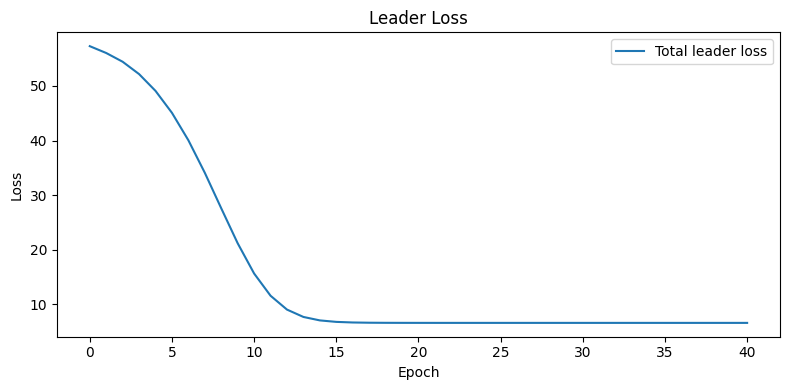

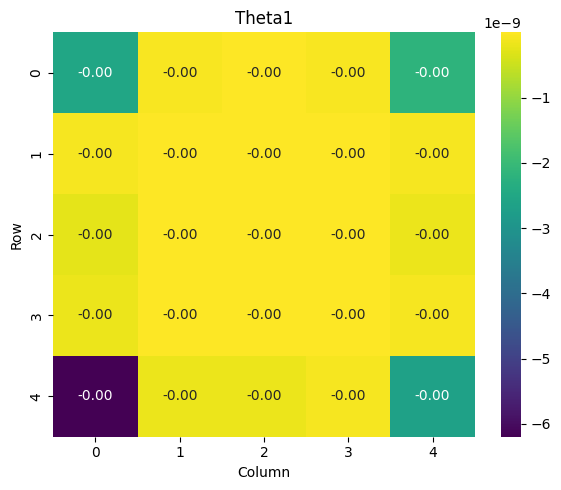

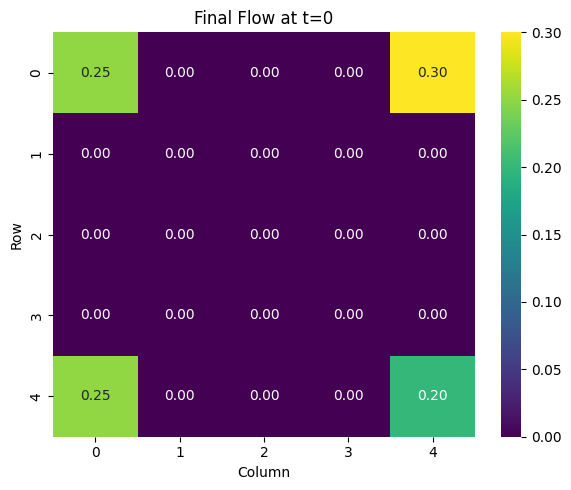

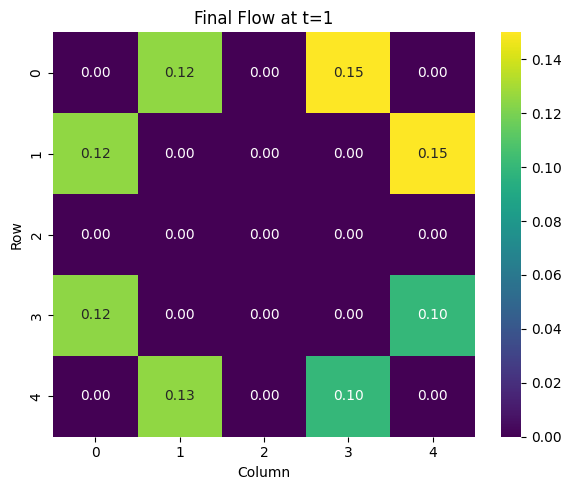

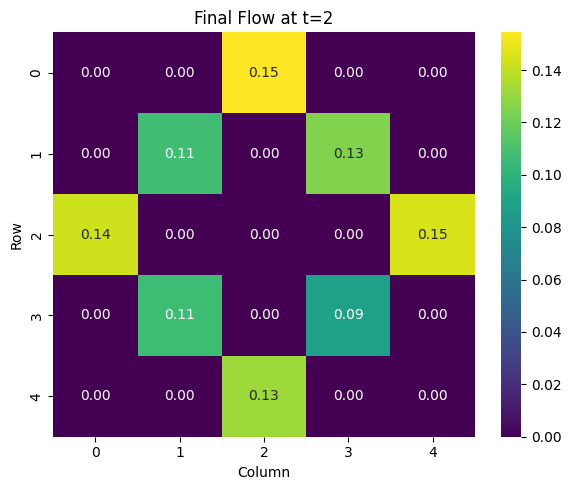

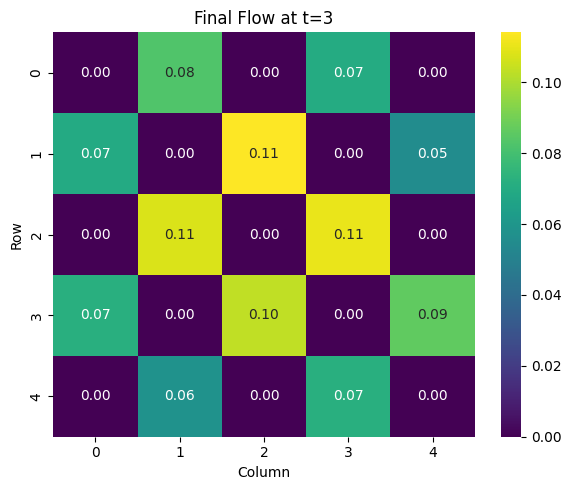

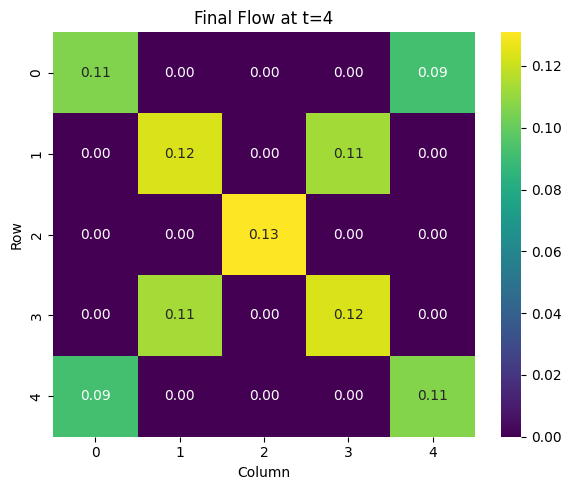

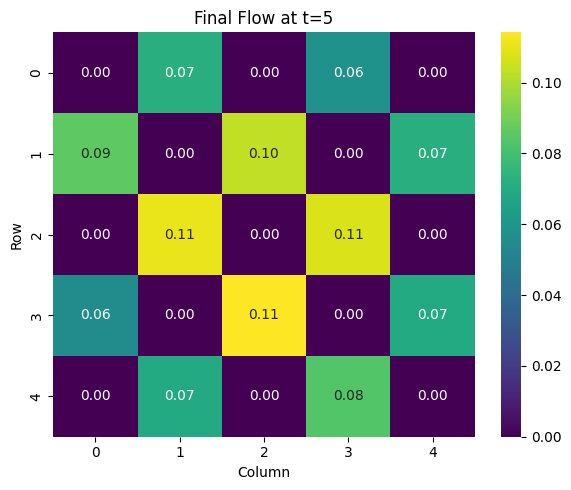

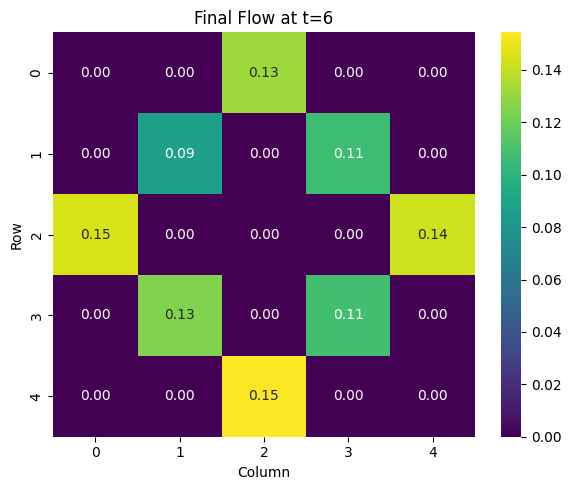

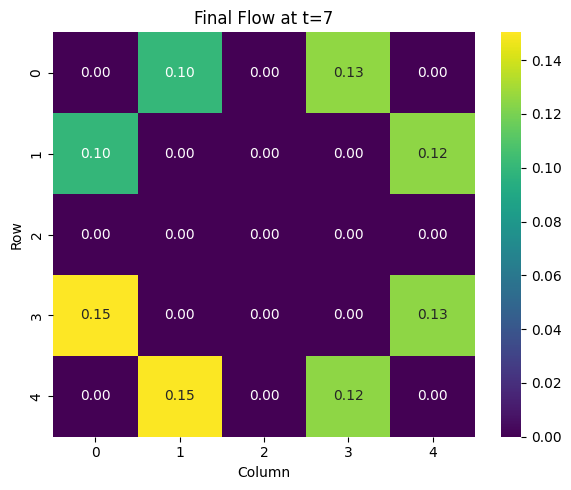

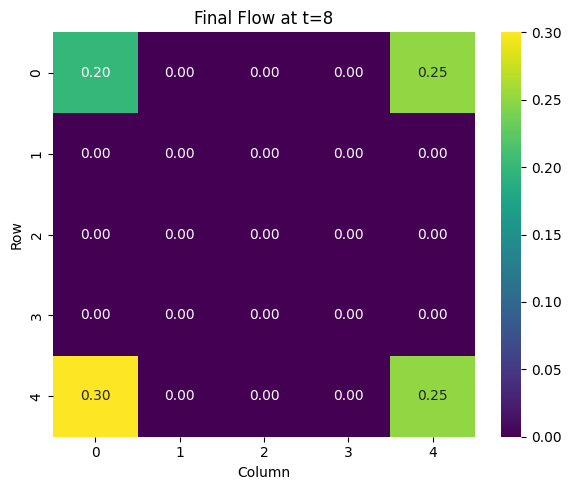

In [ ]:
final_flow_4, losses_4, theta1_4 = run_amid_multigroup()

plot_heatmap(theta1_4[0].cpu().detach().numpy(), title="Theta1", xlabel="Column", ylabel="Row")

for i in range(final_flow_4.shape[0]):
    plot_heatmap(final_flow_4[i].cpu().detach().numpy(), title=f"Final Flow at t={i}", xlabel="Column", ylabel="Row")

In [ ]:
# ════════════════════════════════════════════════════════════
# USAGE EXAMPLES: Running with different config files
# ════════════════════════════════════════════════════════════

# Example 1: Small config for quick testing
print("=" * 50)
print("Running with SMALL config...")
print("=" * 50)
final_flow_small, losses_small, theta1_small = run_amid_multigroup("config_small.yaml")

# Example 2: Default large config
print("\n" + "=" * 50)
print("Running with DEFAULT config...")
print("=" * 50)
final_flow_default, losses_default, theta1_default = run_amid_multigroup("config.yaml")

# Example 3: Large config for thorough testing
print("\n" + "=" * 50)
print("Running with LARGE config...")
print("=" * 50)
# final_flow_large, losses_large, theta1_large = run_amid_multigroup("config_large.yaml")

# ═══ Comparison ═══
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses_small, label="Small config", linewidth=2)
plt.plot(losses_default, label="Default config", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(losses_default[-20:], label="Default (last 20 epochs)", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Convergence Detail")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


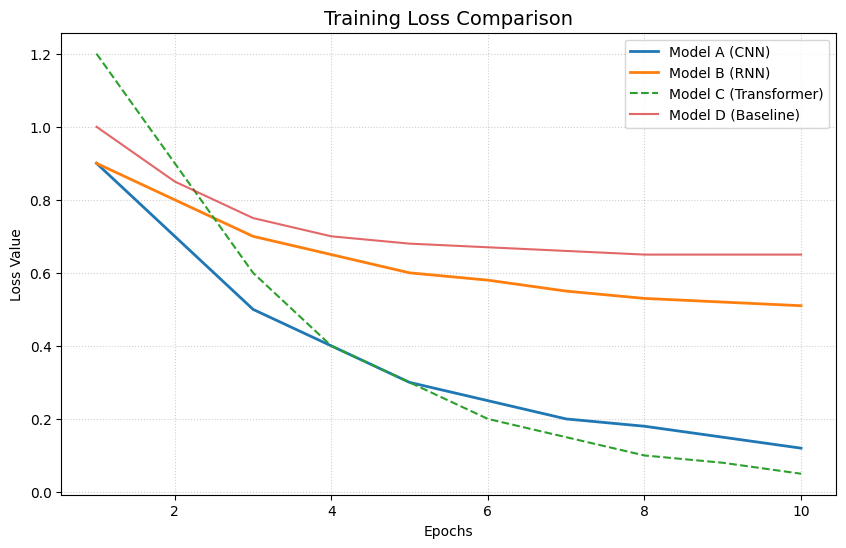

In [ ]:
# Configuration Management Guide

## Overview
Configuration parameters are now managed via YAML files instead of being hardcoded in Python functions. This enables:
- Easy experiment variations
- Reproducibility
- Version control of configs independently from code

## Available Config Files
- `config.yaml` — Default 5×5 grid, 4 groups, 41 epochs
- `config_small.yaml` — 3×3 grid, 2 groups, 20 epochs (fast testing)
- `config_large.yaml` — 10×10 grid, 4 groups, 100 epochs (thorough testing)

## How to Use

### Run with default config:
```python
final_flow, losses, theta1 = run_amid_multigroup()
```

### Run with specific config:
```python
final_flow, losses, theta1 = run_amid_multigroup("config_small.yaml")
```

## YAML Structure

### Grid Configuration
- `rows`, `cols` — Grid dimensions
- `obstacles` — List of obstacle positions (optional)

### Groups Configuration
Each group needs:
- `source` — [row, col] starting position
- `sink` — [row, col] target position
- `mass` — Amount of agents in this group

### Solver Configuration (per-group)
- `eta` — Learning rate
- `tau` — Temperature parameter
- `T` — Horizon
- `alpha` — Congestion penalty weight
- `H` — Number of time steps

### Trainer Configuration
- `leader_lr` — Leader network learning rate
- `num_epochs` — Number of training epochs

### Device
- `device` — "cuda" or "cpu"

## Creating New Configs

To create `config_custom.yaml`:
1. Copy an existing config as template
2. Modify parameters
3. Run: `run_amid_multigroup("config_custom.yaml")`

## Advanced: Loading Custom Configs at Runtime

```python
# Load config and inspect parameters
config = load_config("config_small.yaml")
print(f"Grid size: {config['grid']['rows']} × {config['grid']['cols']}")
print(f"Number of groups: {len(config['groups'])}")
print(f"Number of epochs: {config['trainer']['num_epochs']}")
```
